# Tokyo Airbnb Analysis
## Where is the Best Value for Backpackers?

**Data Source:** Inside Airbnb (September 2025 snapshot)  
**Analysis Goals:**
- Understand price distribution across room types in Tokyo
- Identify the most cost-effective neighborhoods for budget travelers
- Provide data-driven accommodation recommendations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/Users/rocky/Documents/listings.csv', dtype=str)
df = df.copy()

# Preview
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (27945, 18)

Columns: ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license']


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,197677,Oshiage Holiday Apartment,964081,Yoshimi & Marek,NaN,Sumida Ku,35.71707,139.82608,Entire home/apt,12600,3,190,2025-08-24,1.11,1,183,10,M130003350
1,776070,Kero-kero room 1F,801494,Kei,NaN,Kita Ku,35.73844,139.76917,Private room,10459,3,272,2025-05-21,1.74,1,76,14,M130000243
2,905944,4F Spacious Apartment in Shinjuku / Shibuya Tokyo,4847803,Best Stay In Tokyo!,NaN,Shibuya Ku,35.67878,139.67847,Entire home/apt,33671,5,281,2025-09-21,1.85,9,305,50,Hotels and Inns Business Act | 渋谷区保健所長 | 31渋健生...
3,1016831,5 mins Shibuya Cat modern sunny Shimokita,5596383,Wakana,NaN,Setagaya Ku,35.658,139.67134,Private room,24143,1,284,2025-09-21,1.87,1,80,16,M130001107
4,1196177,Homestay at Host's House - Senju-Ohashi Station,5686404,Yukiko,NaN,Adachi Ku,35.74363,139.79852,Private room,8795,2,150,2025-09-07,1.01,1,253,25,M130007760


In [2]:
# Clean price column
df['price'] = df['price'].str.replace(r'[$,]', '', regex=True).astype(float)

# Remove outliers using IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[(df['price'] >= Q1 - 1.5 * IQR) & 
              (df['price'] <= Q3 + 1.5 * IQR)]

print(f"Original rows: {len(df)}")
print(f"After cleaning: {len(df_clean)}")
print(f"Removed: {len(df) - len(df_clean)} outliers")
print(f"\nPrice range after cleaning: ¥{df_clean['price'].min():,.0f} - ¥{df_clean['price'].max():,.0f}")

Original rows: 27945
After cleaning: 23765
Removed: 4180 outliers

Price range after cleaning: ¥1,500 - ¥45,804


## 2. Room Type Analysis
Which room type is most common, and which is most expensive?


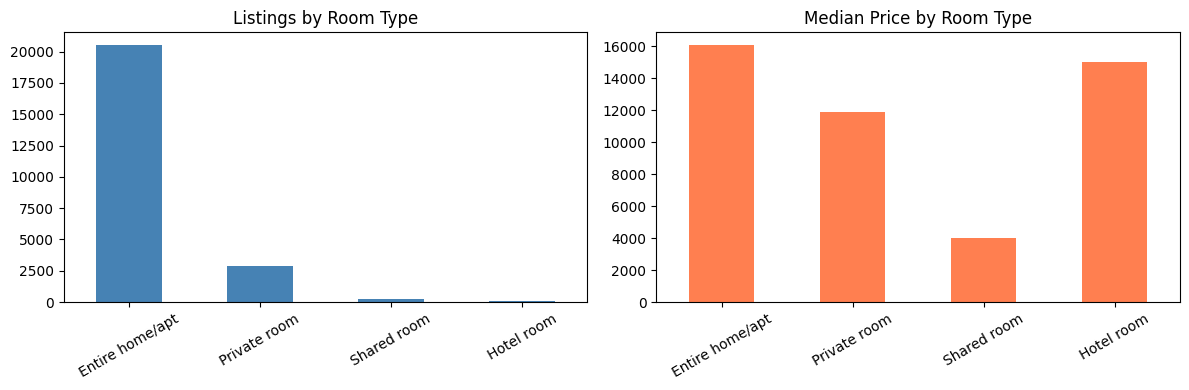

,Mean Price (¥),Median Price (¥),Count
room_type,,,
Entire home/apt,18365.749622,16065.0,20513
Private room,14263.602679,11900.0,2912
Shared room,5131.562992,4001.0,254
Hotel room,15634.046512,15036.5,86


In [3]:
room_ana = df_clean.groupby('room_type')['price'].agg(['mean', 'median', 'count'])
room_ana.columns = ['Mean Price (¥)', 'Median Price (¥)', 'Count']
room_ana = room_ana.sort_values('Count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

room_ana['Count'].plot(kind='bar', ax=axes[0], title='Listings by Room Type', color='steelblue')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

room_ana['Median Price (¥)'].plot(kind='bar', ax=axes[1], title='Median Price by Room Type', color='coral')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

room_ana

## 3. Neighborhood Price Analysis
Which areas are most expensive? (min. 100 listings for statistical reliability)

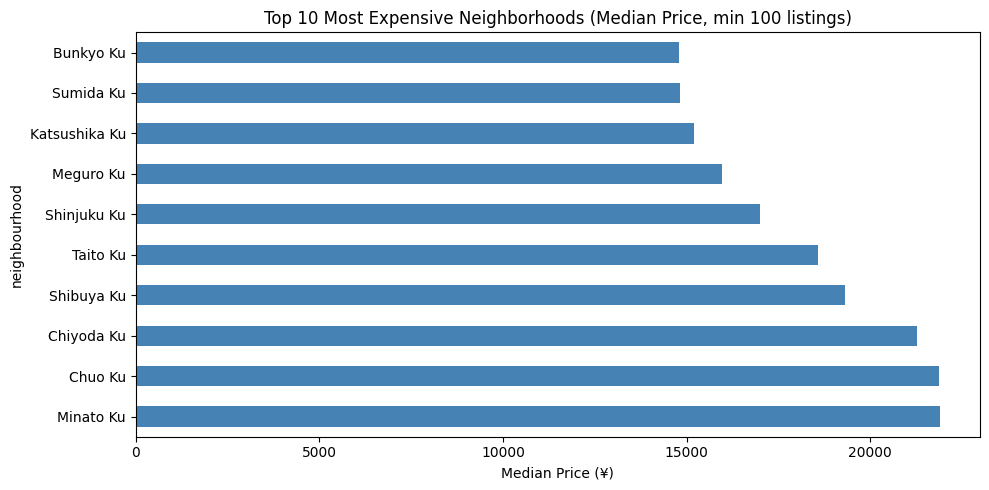

In [4]:
top_areas = df_clean.groupby('neighbourhood')['price'].agg(['mean', 'median', 'count'])
top_areas_filtered = top_areas[top_areas['count'] >= 100]

top_areas_filtered['median'].sort_values(ascending=False).head(10).plot(
    kind='barh', figsize=(10, 5), color='steelblue',
    title='Top 10 Most Expensive Neighborhoods (Median Price, min 100 listings)'
)
plt.xlabel('Median Price (¥)')
plt.tight_layout()
plt.show()

## 4. Best Value for Backpackers
Private room value score = reviews per month ÷ price  
(Higher score = more popular relative to price)

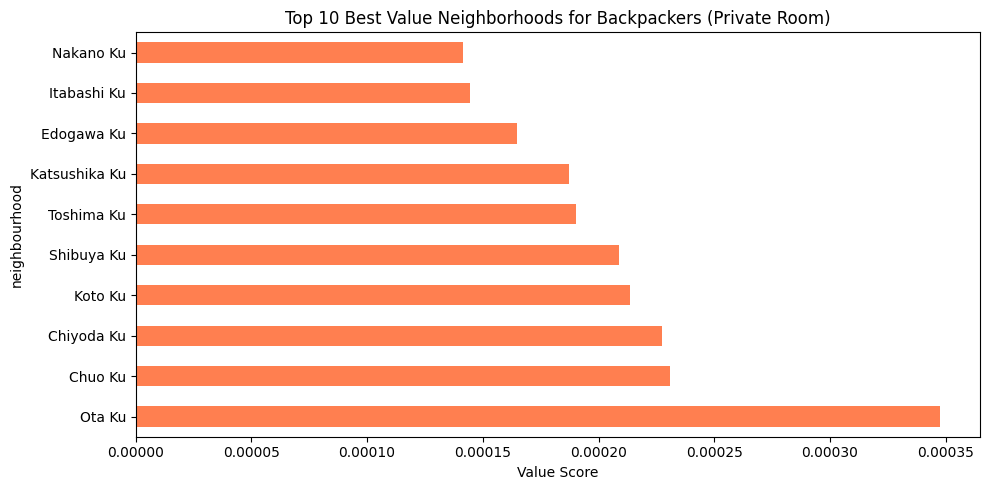

In [5]:
private = df_clean[df_clean['room_type'] == 'Private room'].copy()
private['reviews_per_month'] = pd.to_numeric(private['reviews_per_month'], errors='coerce')
private['value_score'] = private['reviews_per_month'] / private['price']

value_ana = private.groupby('neighbourhood')['value_score'].agg(['mean', 'count'])
value_filtered = value_ana[value_ana['count'] >= 50]

value_filtered['mean'].sort_values(ascending=False).head(10).plot(
    kind='barh', figsize=(10, 5), color='coral',
    title='Top 10 Best Value Neighborhoods for Backpackers (Private Room)'
)
plt.xlabel('Value Score')
plt.tight_layout()
plt.show()

## 5. Key Findings

**1. Entire home/apt dominates the market**  
Over 86% of listings are entire homes, but at ¥16,065 median — nearly 35% more expensive than private rooms.

**2. Location matters more than room type for price**  
Minato Ku (港区) commands the highest median price (¥21,896) among well-represented neighborhoods, driven by its upscale residential character (Roppongi, Azabu). Meanwhile, Shinjuku — the most listed area — is mid-range due to high supply and tourist competition